# [LAB 12] 2-1. 회귀분석의 가정 검정

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from jussam import load_data
from helpers import *
from pandas import DataFrame, melt

import seaborn as sb
import numpy as np

# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, kstest
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

직전 예제와 동일한 데이터

In [2]:
origin = load_data('cars')
origin.head()

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


### 3. 단순선형회귀

In [3]:
fit = my_ols.fit_model(origin, y='dist')
fit

## #02. 가정 검정을 위한 준비

### 1. 예측값을 직접 구하기

In [4]:
y_pred = my_ols.predict(fit, origin[['speed']])
y_pred.head()

,pred
0,-1.849
1,-1.849
2,9.948
3,9.948
4,13.880


### 2. 회귀분석 결과 객체 안에 내장되어 있는 예측값

- 모델 적합(=학습)에 사용된 데이터에 대한 예측값은 fit 객체 안에 내장되어 있으므로 `predict()`로 계산하지 않아도 사용 가능
  - 학습에 사용된 데이터 외에 새로운 데이터에 대한 예측치를 얻고자 할 경우에는 `predict()`만 사용 가능

In [5]:
y_pred_values = fit.fittedvalues    # 모델에 내장된 예측값
y_pred_values.head()                # 상위 5건 확인

0   -1.849
1   -1.849
2    9.948
3    9.948
4   13.880
dtype: float64

### 3. 잔차 - 직접 구하기

- $종속변수 - 예측값$
  - `y_pred['pred']` : `predict()`로 얻은 예측값
  - `y_pred_values` : `fit.fittedvalues`로 얻은 예측값

In [6]:
# 잔차 = 실제 종속변수 - 예측값
# residual = origin['dist'] - y_pred['pred']

# 위 코드와 아래 코드의 결과는 동일함
residual = origin['dist'] - y_pred_values

# 상위 5건 확인
residual.head()

0    3.849
1   11.849
2   -5.948
3   12.052
4    2.120
dtype: float64

### 4. 회귀분석 결과에 내장된 잔차 가져오기

- 모델 적합(=학습)에 사용된 데이터에 대한 예측값을 통해 얻은 잔차는 fit 객체에 내장되어 있으므로 직접 계산하지 않고 사용 가능

In [7]:
# 직전 코드와 동일한 결과이다.
residual_values = fit.resid     # 내장되어 있는 잔차
residual_values.head()          # 상위 5건 확인

0    3.849
1   11.849
2   -5.948
3   12.052
4    2.120
dtype: float64

### 5. 잔차를 분석 데이터에 결합

- 이후 진행되는 가정 검정에 잔차를 활용해야 하므로 원본 데이터와 결합한다.

In [8]:
ols_df = origin.copy()                  # 원본 데이터 복사
ols_df['y_pred'] = fit.fittedvalues     # 복사한 데이터에 예측값 추가
ols_df['resid'] = fit.resid             # 복사한 데이터에 잔차 추가
ols_df.head()                           # 상위 5건 확인

,speed,dist,y_pred,resid
0,4,2,-1.849,3.849
1,4,10,-1.849,11.849
2,7,4,9.948,-5.948
3,7,22,9.948,12.052
4,8,16,13.880,2.120


## #03. 선형성 검정

### 1. 시각화를 통한 검정

- 예측값에 따른 잔차에 대한 산점도+추세선 그래프를 그린다.
- 모든 예측값에서 가운데 점선에 맞추어 잔차가 비슷하게 있어야 한다.
- 빨간 실선은 잔차의 추세를 의미
  - 빨간 실선이 점선에서 크게 벗어난다면 잔차가 크게 달라진다는 의미이므로 선형성이 없다는 것이다.

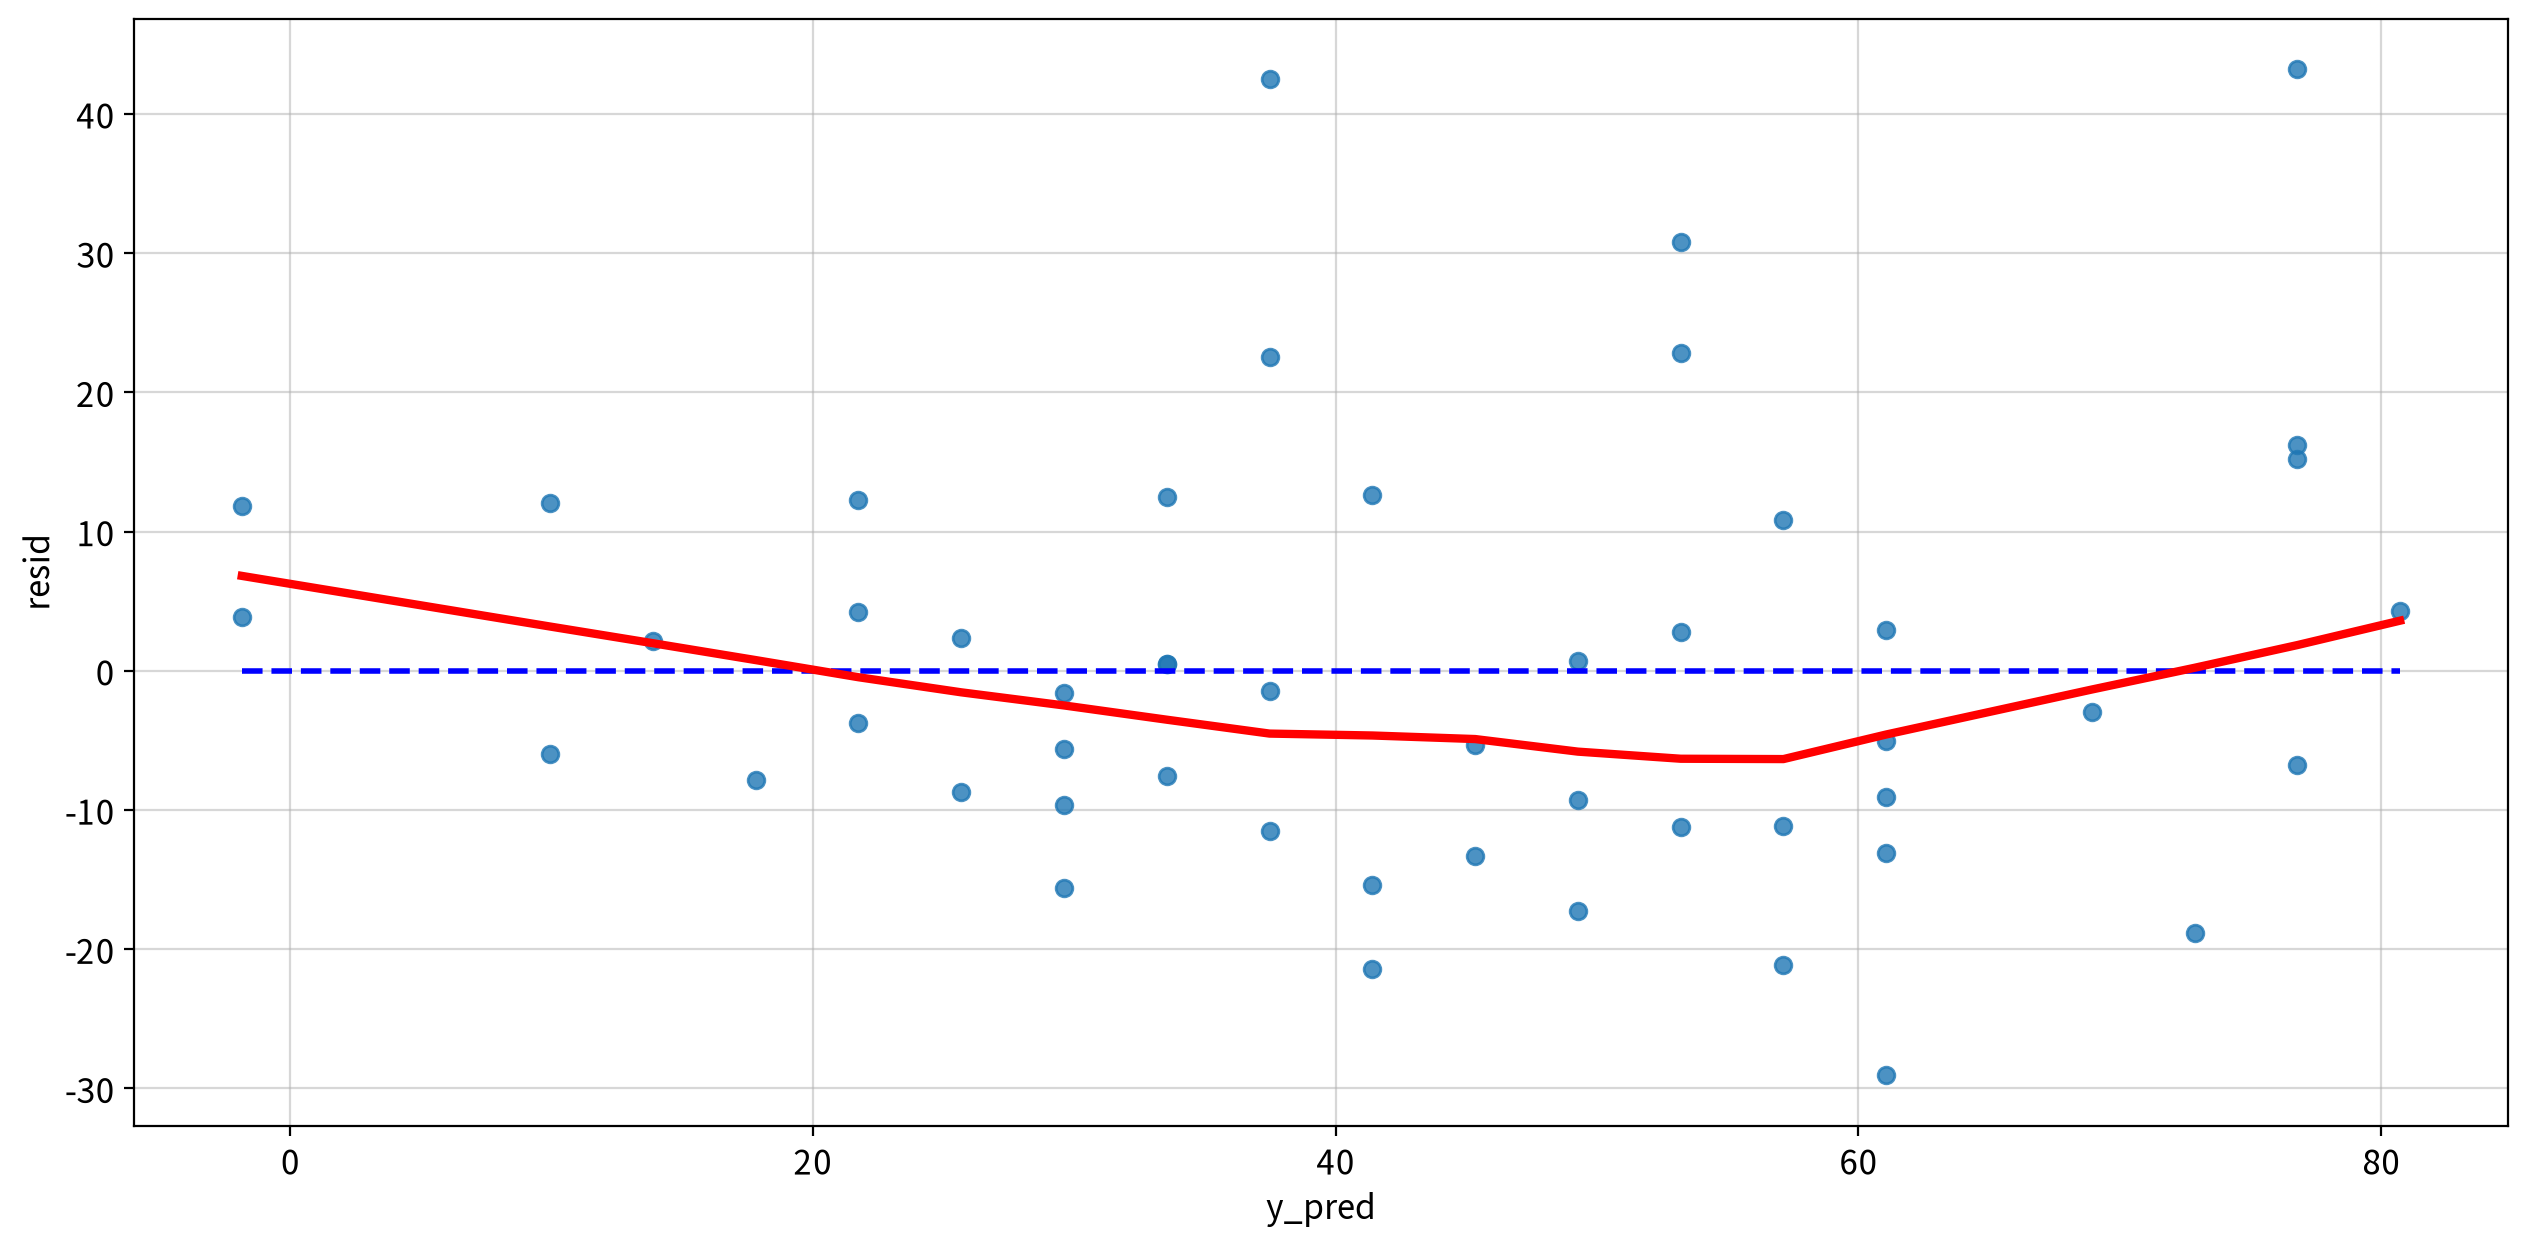

In [9]:
xmin = ols_df['y_pred'].min()   # 예측값(y_pred)의 최솟값 → 기준선을 그릴 x축 시작점
xmax = ols_df['y_pred'].max()   # 예측값(y_pred)의 최댓값 → 기준선을 그릴 x축 끝점
xrange = [xmin, xmax]           # 기준선의 x좌표 범위 (시작점 ~ 끝점)
yrange = [0, 0]                 # 기준선의 y좌표 (잔차=0을 나타내는 수평선이므로 양 끝 모두 0)

fig, ax = my_plot.init()        # 그래프(figure)와 축(axes) 객체 생성

# 잔차=0 기준선을 파란 점선으로 그리기 (잔차가 이 선 근처에 고르게 있어야 선형성 만족)
my_plot.lineplot(x=xrange, y=yrange, color='blue', linestyle='--', ax=ax)

# 예측값 대비 잔차 산점도 + lowess(비선형) 추세선(빨강) → 곡선으로 휘면 선형성 위배 신호
sb.regplot(data=ols_df, x='y_pred', y='resid', lowess=True, line_kws={'color': 'red'}, ax=ax)

my_plot.show()                  # 완성된 그래프 출력

#### 인사이트

- **빨간 lowess 추세선이 파란 기준선(잔차=0) 근처에 대체로 붙어 있다.** 예측값이 낮은 구간에서 살짝 위(+), 중간 구간에서 살짝 아래(−), 높은 구간에서 다시 위로 올라오는 **완만한 물결 모양**이 보이지만, 그 진폭은 잔차 자체의 흩어진 폭에 비하면 작다.
- 즉, 곡선이 위로 볼록하거나 아래로 볼록한 **뚜렷한 곡선 패턴(U자·포물선)이 나타나지 않으므로 선형성 가정은 대체로 충족**된다고 볼 수 있다
- 다만 **예측값이 커질수록 잔차의 산포(위아래 폭)가 다소 넓어지는 부채꼴 경향**이 약하게 보인다. 이는 선형성보다는 **등분산성**과 관련된 신호이므로, 뒤의 *등분산성(브로이슈–패건) 검정* 에서 확인이 필요하다.
- 오른쪽 위(예측값이 가장 큰 지점)에 **잔차가 유난히 큰 관측치 하나**가 눈에 띈다.

### 2. 통계량을 통한 검정  - Ramsey RESET Test

시각적 판단이 애매할 때 사용하는 **선형성(모형 설정 오류) 검정**

#### 가설·수식·내용

| 구분 | 수식 | 내용 |
|---|---|---|
| **귀무가설 $H_0$** | $\gamma_1 = \gamma_2 = \dots = 0$ | 추가한 고차항이 모두 0 → **선형 모형으로 충분**(선형성 위배 근거 없음) |
| **대립가설 $H_1$** | 적어도 하나의 $\gamma_j \neq 0$ | 고차항이 유의미 → **곡선 관계 존재**(선형성 위배) |
| **판정 기준** | $p\text{-value} < 0.05$ | 참이면 $H_0$ 기각 → **선형성 위배 가능**, 아니면 → **위배 근거 없음** |

In [10]:
reset_res = linear_reset(fit, power=2, use_f=True)
print(f'RESET 검정 결과: F-statistic={reset_res.fvalue:.4f}, p-value={reset_res.pvalue:.4f}')

RESET 검정 결과: F-statistic=2.2960, p-value=0.1364


## #04. 잔차의 정규성 검정

### 1. Q-Q Plot (1) - 잔차의 z- score 구하기

In [11]:
# 정규성은 '잔차(resid)'에 대한 가정이므로 잔차를 표준화(zscore)한다.
# (주의: 예측값 y_pred를 쓰면 안 된다.
#  단순회귀에서 y_pred는 speed의 선형변환이라 잔차의 정규성과 무관)
ols_df['zscore'] = zscore(ols_df['resid'])
ols_df.head()

,speed,dist,y_pred,resid,zscore
0,4,2,-1.849,3.849,0.255
1,4,10,-1.849,11.849,0.786
2,7,4,9.948,-5.948,-0.395
3,7,22,9.948,12.052,0.800
4,8,16,13.880,2.120,0.141


### 2. Q-Q Plot (2) - Q-Q 플롯의 좌표 구하기

In [12]:
(x, y), _ = probplot(ols_df['zscore'])  # 그래프의 x, y 좌표를 반환

ols_df['qq_x'] = x      # Q-Q plot의 x좌표
ols_df['qq_y'] = y      # Q-Q plot의 y좌표

ols_df.head()           # 상위 5건 확인

,speed,dist,y_pred,resid,zscore,qq_x,qq_y
0,4,2,-1.849,3.849,0.255,-2.204,-1.929
1,4,10,-1.849,11.849,0.786,-1.833,-1.421
2,7,4,9.948,-5.948,-0.395,-1.614,-1.403
3,7,22,9.948,12.052,0.800,-1.453,-1.252
4,8,16,13.880,2.120,0.141,-1.323,-1.146


### 3. Q-Q Plot (3) - Q-Q 플롯 그리기

zscore에 대한 산점도 그래프이다.

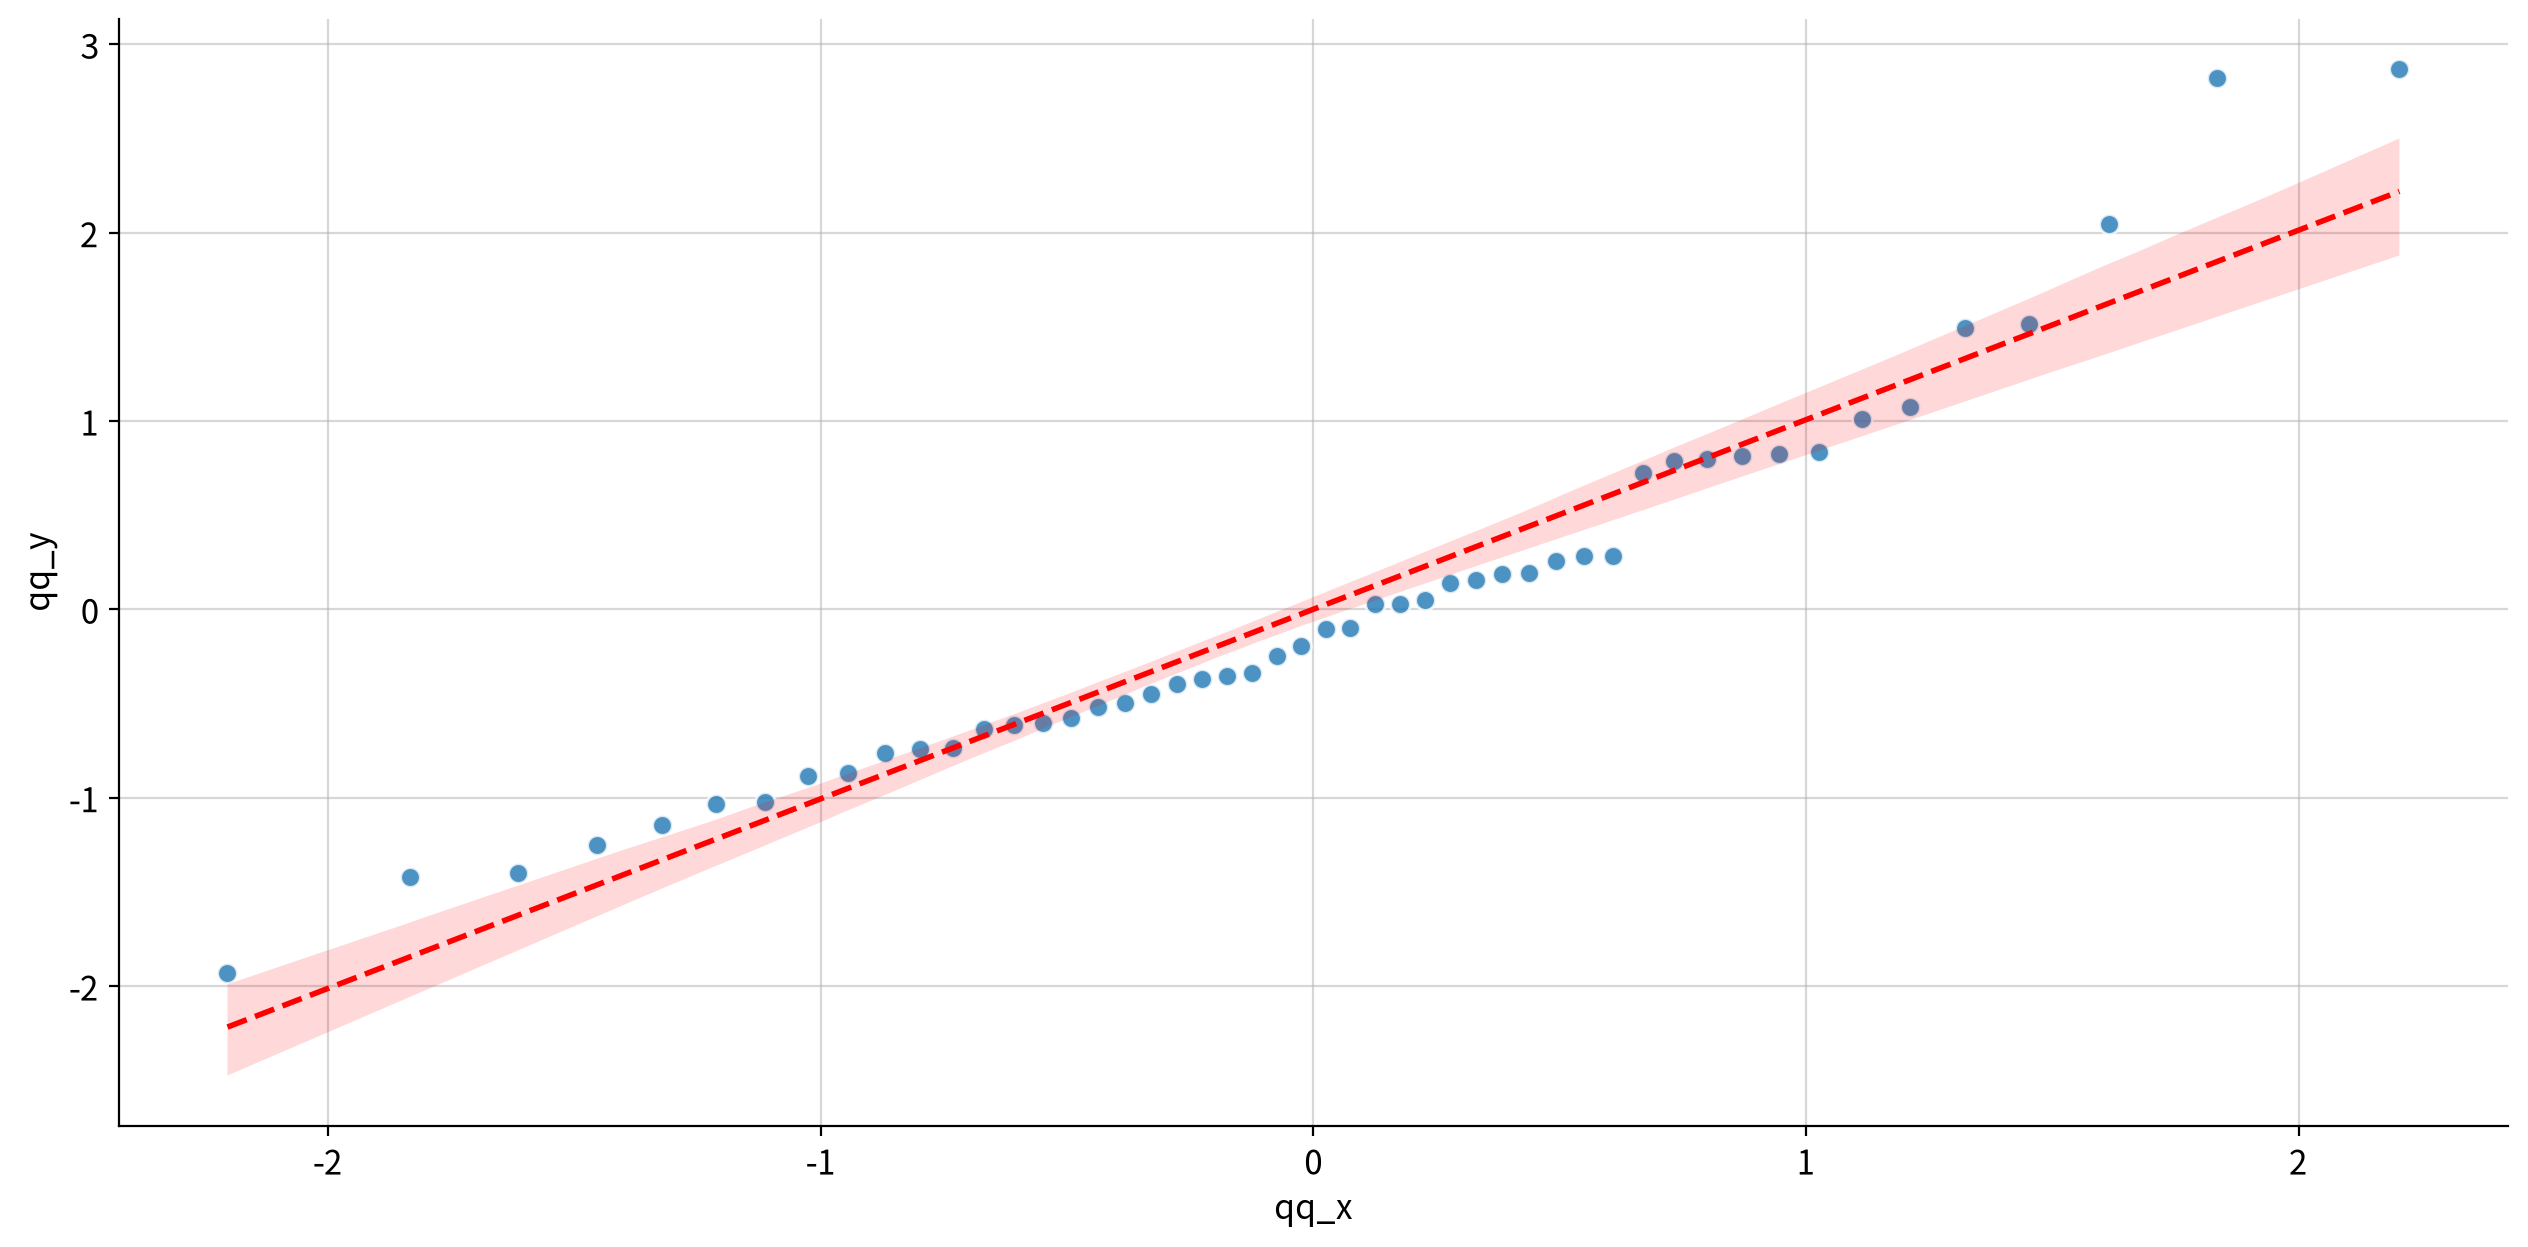

In [13]:
my_plot.lmplot(ols_df, x='qq_x', y='qq_y', linecolor='red', linestyle="--")

#### 인사이트

- **점들이 빨간 기준선(45°)에 대체로 잘 올라타 있다.** → 잔차가 정규분포에 가까움
- **양쪽 꼬리에서 점이 선을 살짝 벗어난다.** 특히 위쪽 끝점이 선 위로 뜸 → 오른쪽으로 약간 두꺼운 꼬리

### 4. $\sqrt{MSE}$ 구간별 비율 구하기

In [14]:
MSE_sq = np.sqrt(fit.mse_resid) # 잔차 표준오차
r = fit.resid   # 잔차
n = r.count()   # 표본수

# 잔차가 -√MSE ~ +√MSE 구간에 있는 경우의 비율 : 68% 이내여야 함
r1 = r[ (r > -MSE_sq) & (r < MSE_sq)].count() / r.count() * 100

# 잔차가 -2√MSE ~ +2√MSE 구간에 있는 경우의 비율: 95% 이내여야 함
r2 = r[ (r > -2*MSE_sq) & (r < 2*MSE_sq)].count() / r.count() * 100

# 잔차가 -3√MSE ~ +3√MSE 구간에 있는 경우의 비율: 99.7% 이내여야 함
r3 = r[ (r > -3*MSE_sq) & (r < 3*MSE_sq)].count() / r.count() * 100

# 세 종류의 잔차 비율을 리스트로 묶기
mse_r = [r1, r2, r3]

print(f"√MSE = {MSE_sq:.2f}\n")
print(mse_r)

√MSE = 15.38

[np.float64(74.0), np.float64(94.0), np.float64(100.0)]


### 5. $\sqrt{MSE}$ 구간 규칙을 통한 정규성 판정

In [15]:
expected = [68, 95, 99.7]        # ±1·±2·±3√MSE 구간의 정규분포 기대 비율(%)
mse_judge = []                   # 구간별 규칙 충족 여부

for k, exp, actual in zip([1, 2, 3], expected, mse_r):
    pe = exp / 100                  # 기대 비율을 소수로 변환
    se = np.sqrt(pe * (1 - pe) / n) # 기대 비율의 표준오차
    lo = max(0, pe - 2 * se) * 100  # 허용 범위 하한 (0과 계산값중 큰 값: 0보다 작으면 0으로 처리
    hi = min(1, pe + 2 * se) * 100  # 허용 범위 상한 (1과 계산값중 작은 값: 1보다 크면 1로 처리)
    
    ok = lo <= actual <= hi         # 실제 비율이 허용 범위 안에 있는지 여부 확인
    mse_judge.append(ok)

    print(f"±{k}√MSE 구간: 기대 {exp}%, 허용 구간 {lo:.0f}~{hi:.0f}%, "
          f"실제 {actual:.2f}% → {'충족' if ok else '위배'}")

mse_rule = all(mse_judge)   # 세 구간 모두 충족해야 규칙상 정규성 부합
print(f"\n√MSE 구간 규칙 판정: {'정규성 부합' if mse_rule else '정규성 위배'}")

±1√MSE 구간: 기대 68%, 허용 구간 55~81%, 실제 74.00% → 충족
±2√MSE 구간: 기대 95%, 허용 구간 89~100%, 실제 94.00% → 충족
±3√MSE 구간: 기대 99.7%, 허용 구간 98~100%, 실제 100.00% → 충족

√MSE 구간 규칙 판정: 정규성 부합


### 5. 잔차도 시각화

- 예측값과 실제값간의 잔차를 residplot으로 시각화 한 그래프에 $\sqrt{MSE}$ 구간 규칙을 적용한 그래프

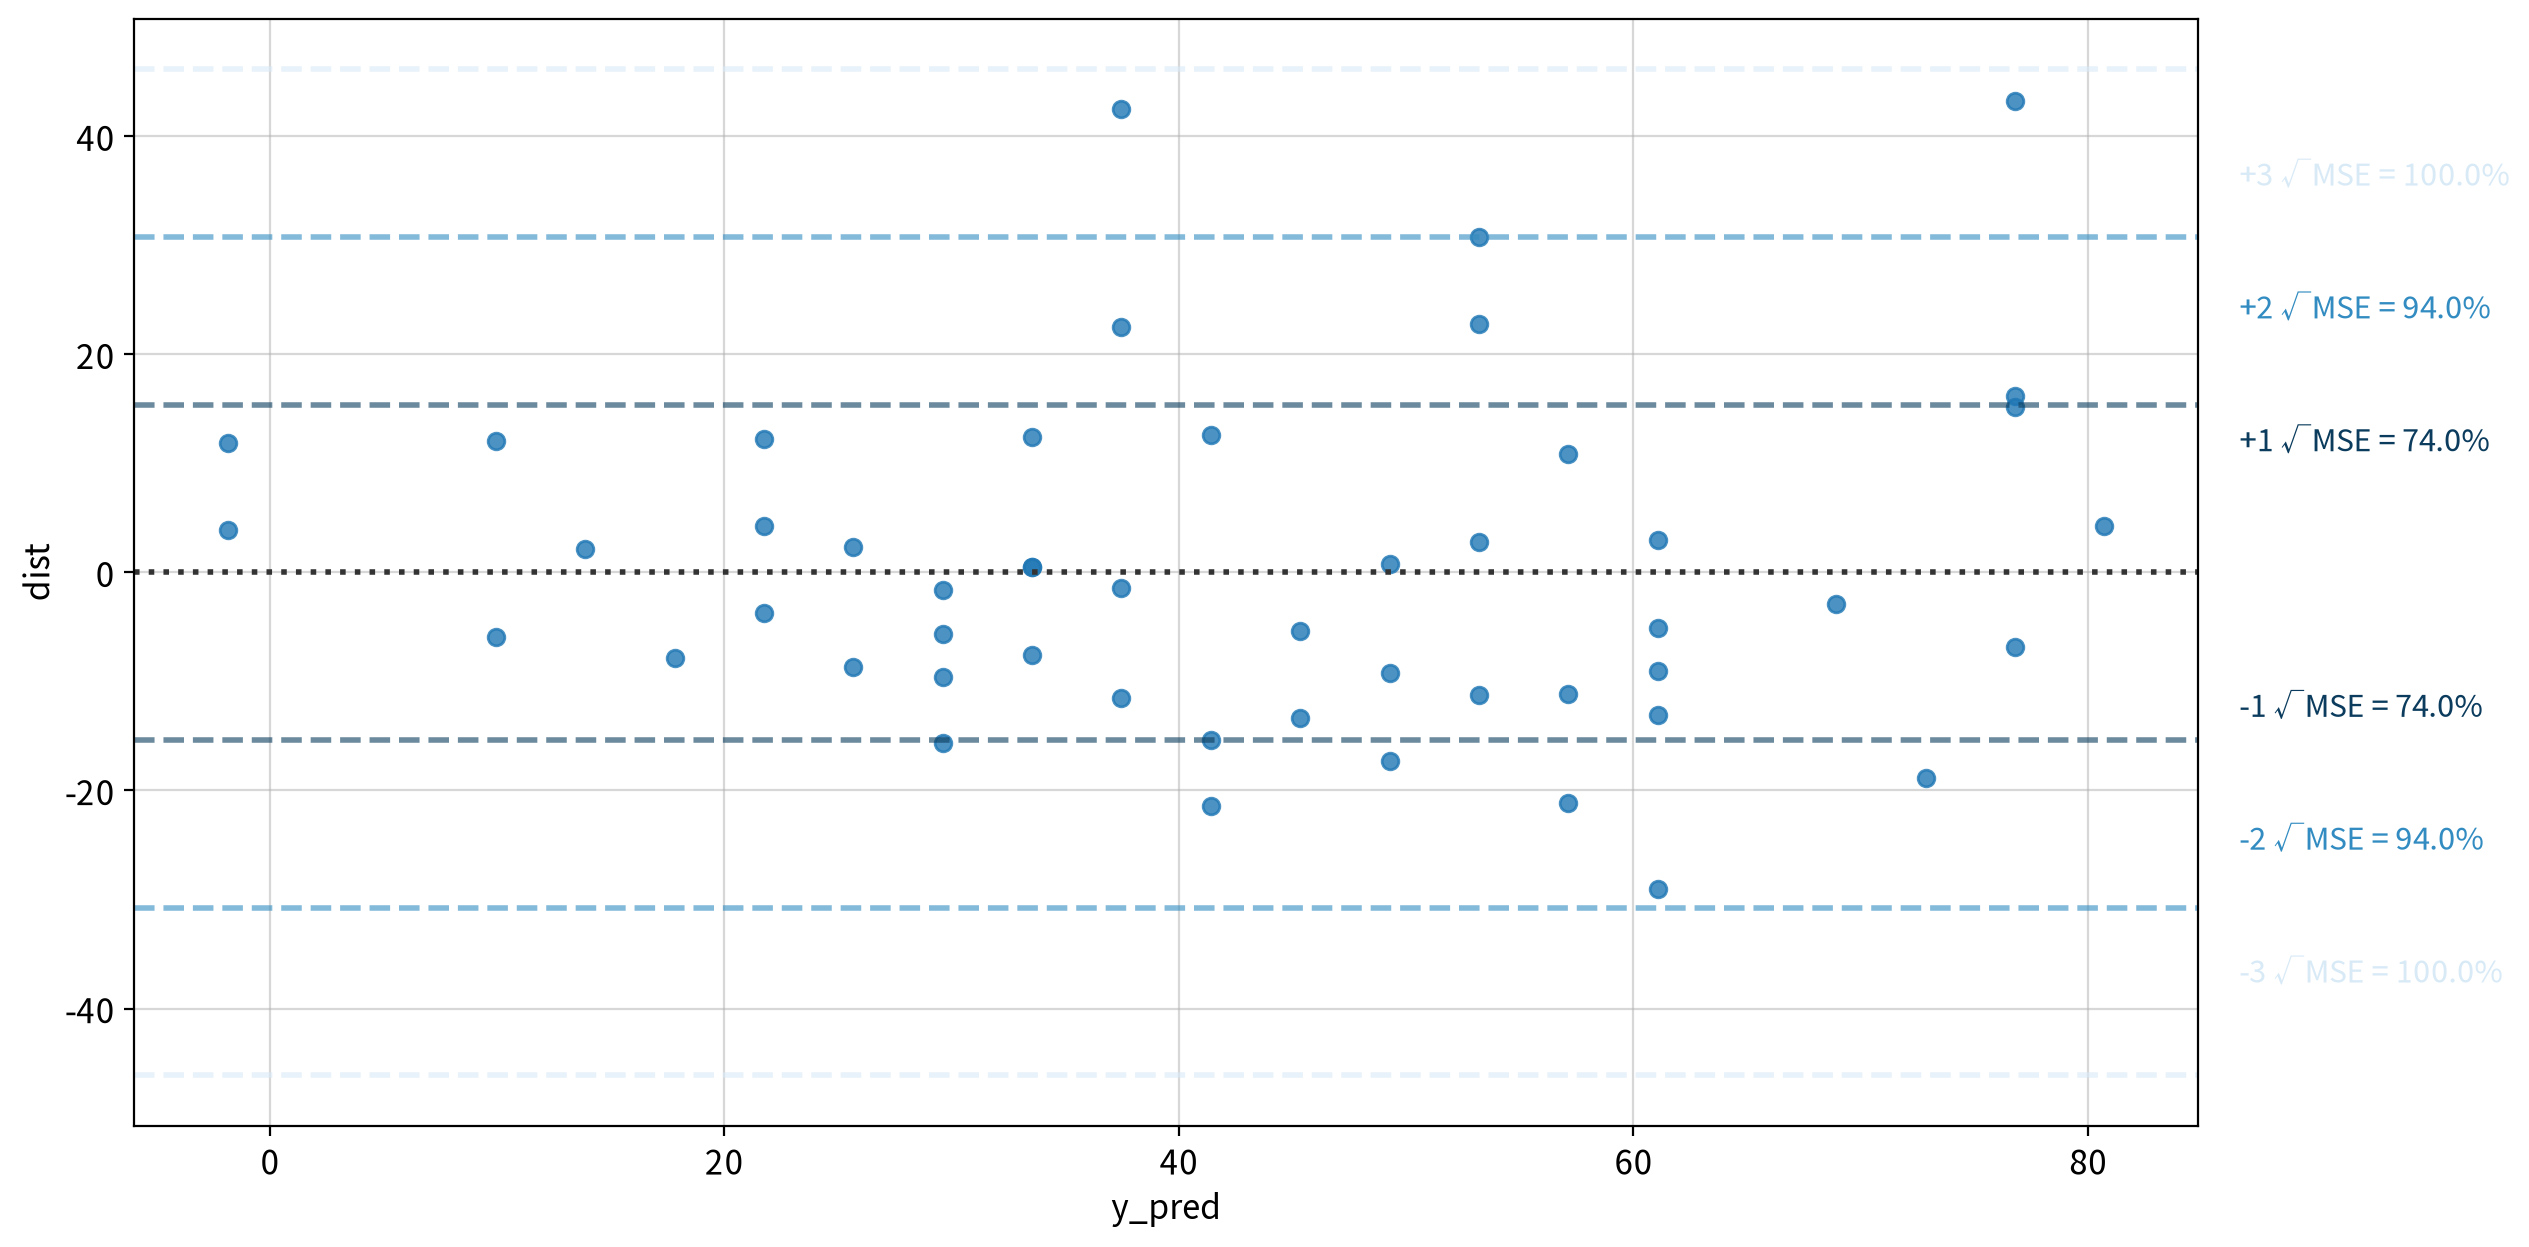

In [16]:
mse_sq = fit.mse_resid                      # 잔차 분산
mse_root = np.sqrt(mse_sq)                  # 잔차 분산의 제곱근
colors = ["#0B3C5D", "#328CC1", "#D9EAF7"]  # 구간별 색상
xmax = ols_df['y_pred'].max()               # 예측값(y_pred)의 최댓값
ymin = ols_df['y_pred'].min()               # 예측값(y_pred)의 최솟값

fig, ax = my_plot.init()                    # 그래프 초기화

# seaborn 기본 잔차도
sb.residplot(data=ols_df, x='y_pred', y="dist", ax=ax)

# MSE 3단계 표시
for i, c in enumerate(colors):  # 반복 단계 안에서: i-> 0, 1, 2 / c-> 색상
    k = i + 1                   # 반복 단계 안에서: 1, 2, 3
    y_pos = k * mse_root        # 반복 단계 안에서: 1√MSE, 2√MSE, 3√MSE

    # 반복이 진행되는 동안 ±1√MSE, ±2√MSE, ±3√MSE 구간을 점선으로 표시
    ax.axhline(y= y_pos,  color=c, linestyle="--", alpha=0.6)
    ax.axhline(y= -y_pos,  color=c, linestyle="--", alpha=0.6)

    # 반복이 진행되는 동안 ±1√MSE, ±2√MSE, ±3√MSE 구간의 실제 비율을 그래프 오른쪽에 표시
    #        x좌표   y좌표              표시문자열                   좌표계 변환(그래프 외부 좌표)
    ax.text(x=1.02, y=0.5 + 0.12*k, s=f"+{k} √MSE = {mse_r[i]}%", transform=ax.transAxes,
            ha="left", va="center", fontsize=11, color=c)
    ax.text(x=1.02, y=0.5 - 0.12*k, s=f"-{k} √MSE = {mse_r[i]}%", transform=ax.transAxes,
            ha="left", va="center", fontsize=11, color=c)

my_plot.show()

### 6. 검정 통계량을 사용한 검정

- 귀무가설 : 표본의 모집단이 정규분포를 따름
- 대립가설 : 표본의 모집단이 정규분포를 따르지 않음

In [17]:
# 샘플 수에 따라 정규성 검정 선택
if len(origin) < 30:                    # 샘플 수가 30 미만이면 Shapiro-Wilk 검정 사용
    method = "Shapiro-Wilk"
    s, p = shapiro(ols_df['resid'])
else:                                   # 샘플 수가 30 이상이면 Kolmogorov-Smirnov 검정 사용
    method = "Kolmogorov–Smirnov"

    mu = ols_df['resid'].mean()             # 잔차의 평균
    sigma = ols_df['resid'].std(ddof=1)     # 잔차의 표준편차
    z = (ols_df['resid'] - mu) / sigma      # 잔차를 표준화(zscore)하여 정규분포로 변환
    s, p = kstest(z, 'norm')                # 변환된 값이 정규분포(norm)를 따르는지 검정

print(f"{method} 검정 결과: statistic={s:.4f}, p-value={p:.4f}")

Kolmogorov–Smirnov 검정 결과: statistic=0.1296, p-value=0.3410


## #05. 잔차의 등분산성

### 1. 브로이슈-패건 검정

| 가설 | 설명 |
|---|---|
| 귀무가설 | 등분산성 가정이 만족된다 (오차의 분산은 독립변수들과 관련이 없다) |
| 대립가설 | 등분산성 가정이 만족되지 않는다(오차의 분산은 독립변수들과 관련이 있다) |

In [18]:
# Breusch–Pagan Test
names = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_test = het_breuschpagan(fit.resid, fit.model.exog)
bp = DataFrame(bp_test, index=names, columns=['value'])

# Breusch–Pagan Test 결과 출력
# -> 출력 결과에서 F p-value가 0.05보다 작으면 등분산성 가정 위배
# 나머지 값은 참고하지 않아도 무관하다.
display(bp)

,value
LM Statistic,3.215
LM p-value,0.073
F Statistic,3.298
F p-value,0.076


## #06. 잔차의 독립성

### 1. Dubin-Watson

In [19]:
dw = durbin_watson(ols_df['resid'])

if 1.5 <= dw <= 2.5:
    interpretation = "잔차는 독립성을 만족함"
elif dw < 1.5:
    interpretation = "잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)"
else:
    interpretation = "잔차에 음(–)의 자기상관이 존재할 가능성 있음 (독립성 위반)"

print(f"Durbin–Watson = {dw:.3f} ::: {interpretation}")

Durbin–Watson = 1.676 ::: 잔차는 독립성을 만족함
